In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
import nltk
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout,LSTM,GRU
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)


In [ ]:
'''

splits = {'train': 'train_df.csv', 'validation': 'val_df.csv', 'test': 'test_df.csv'}
df = pd.read_csv("hf://datasets/Sp1786/multiclass-sentiment-analysis-dataset/" + splits["train"])
'''

'\n\nsplits = {\'train\': \'train_df.csv\', \'validation\': \'val_df.csv\', \'test\': \'test_df.csv\'}\ndf = pd.read_csv("hf://datasets/Sp1786/multiclass-sentiment-analysis-dataset/" + splits["train"])\n'

### data explotation

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "sentiment_data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "abdelmalekeladjelet/sentiment-analysis-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_1851/2490920701.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 22.8M/22.8M [00:02<00:00, 8.04MB/s]


First 5 records:    Unnamed: 0                                            Comment  Sentiment
0           0  lets forget apple pay required brand new iphon...          1
1           1  nz retailers don’t even contactless credit car...          0
2           2  forever acknowledge channel help lessons ideas...          2
3           3  whenever go place doesn’t take apple pay doesn...          0
4           4  apple pay convenient secure easy use used kore...          2


In [ ]:

n_per_class = 33333

df_40k = (
    df.groupby('Sentiment', group_keys=False)
      .apply(lambda x: x.sample(n=n_per_class, random_state=42))
      .reset_index(drop=True)
)

print(df_40k['Sentiment'].value_counts())


Sentiment
0    33333
1    33333
2    33333
Name: count, dtype: int64


/tmp/ipykernel_1851/1056519955.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=n_per_class, random_state=42))


In [ ]:
df=df_40k

In [ ]:
df.head()

,Unnamed: 0,Comment,Sentiment
0,50826,safeway bathroom still smells like ass,0
1,8005,calling someone “racist” “phobic” evidence bac...,0
2,10308,roast anybody without making feel bad,0
3,144702,plz send shah pakistan modi destroy economy th...,0
4,109841,recent survey teamlease services showed millio...,0


In [ ]:
df['Sentiment'].unique()

array([0, 1, 2])

In [ ]:
df.shape

(99999, 3)

In [ ]:
df.describe()

,Unnamed: 0,Sentiment
count,99999.000000,99999.000000
mean,120935.138281,1.000000
std,69282.381305,0.816501
min,1.000000,0.000000
25%,60885.500000,0.000000
50%,119979.000000,1.000000
75%,180881.500000,2.000000
max,241925.000000,2.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  99999 non-null  int64 
 1   Comment     99910 non-null  object
 2   Sentiment   99999 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 2.3+ MB


### Exploration Data Analysis

In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
Comment,89
Sentiment,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

empty texts

In [ ]:
(df['Comment'].str.strip()=='').sum()

np.int64(0)

text length

In [ ]:
df['text_len'] = df['Comment'].str.len()
df['text_len'].describe()

,text_len
count,99910.000000
mean,87.701191
std,71.721520
min,1.000000
25%,41.000000
50%,72.000000
75%,125.000000
max,5080.000000


In [ ]:
df.head()

,Unnamed: 0,Comment,Sentiment,text_len
0,50826,safeway bathroom still smells like ass,0,38
1,8005,calling someone “racist” “phobic” evidence bac...,0,68
2,10308,roast anybody without making feel bad,0,37
3,144702,plz send shah pakistan modi destroy economy th...,0,156
4,109841,recent survey teamlease services showed millio...,0,168


text len distribution

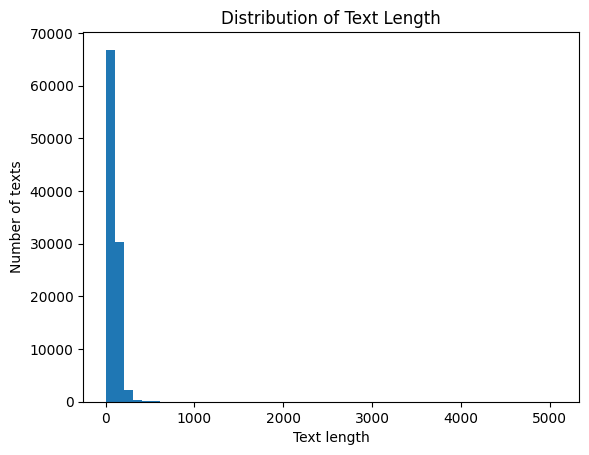

In [ ]:
import matplotlib.pyplot as plt
plt.hist(df['text_len'], bins=50)
plt.xlabel('Text length')
plt.ylabel('Number of texts')
plt.title('Distribution of Text Length')
plt.show()

short text

In [ ]:
short_text = df[df['text_len']<=3]

In [ ]:
print(short_text[['Comment', 'Sentiment']])
short_text.shape

      Comment  Sentiment
545       fun          0
665       day          0
3718      fan          0
5000      wtf          0
7790      yep          0
...       ...        ...
86125     may          2
86942     fun          2
90581     wow          2
95755     wow          2
96332     bad          2

[131 rows x 2 columns]


(131, 4)

In [ ]:
threshold = df['text_len'].quantile(0.99)
print('threshold:',threshold)
long_text = df[df['text_len']>threshold]
print(long_text[['Comment', 'Sentiment']])
long_text.shape

threshold: 254.0
                                                 Comment  Sentiment
84     note self demo version app totally useless way...          0
99     concept good execution lacks constant issues s...          0
216    use mase sunday school teacher atlanta first g...          0
359    syncing doesnt work whole point upgrading pro ...          0
368    loved app recently realized dont use half much...          0
...                                                  ...        ...
99728  shane would highly recommend looking sub reddi...          2
99762  great app want import calendar replace calenda...          2
99849  richard watched videos studied notes two weeks...          2
99896  everyone appreciating greek godlets take momen...          2
99897  looking organizer app would provide statistics...          2

[997 rows x 2 columns]


(997, 4)

In [ ]:
df['Sentiment'].value_counts()

,count
Sentiment,
2,33329
0,33327
1,33254


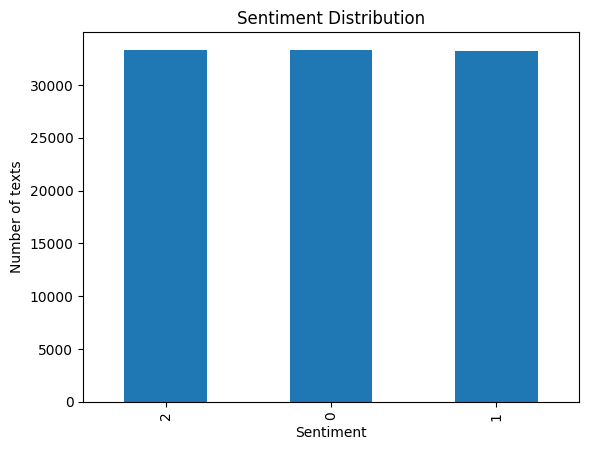

In [ ]:
df['Sentiment'].value_counts().plot(kind='bar')
plt.xlabel('Sentiment')
plt.ylabel('Number of texts')
plt.title('Sentiment Distribution')
plt.show()

In [ ]:
html_count=df['Comment'].str.contains(
      r'<[^>]+>',
    regex=True,
    na=False
).sum()
print("Texts containing HTML:", html_count)

Texts containing HTML: 0


In [ ]:
df['Comment']=df['Comment'].str.replace(
    r'<[^>]+>',
    '',
    regex=True
)

In [ ]:
url_count = df['Comment'].str.contains(
    r'https?://\S+|www\.\S+',
    regex=True,
    na=False
).sum()

print("Comments containing URLs:", url_count)

Comments containing URLs: 0


In [ ]:
df['Comment']=df['Comment'].str.replace(
    r'https?://\S+|www\.\S+',
    '',
    regex=True
)

In [ ]:
df['Comment']=df['Comment'].str.replace(
    r'\s+',
    ' ',
    regex=True
)

In [ ]:
df['Comment'].iloc[2]

'roast anybody without making feel bad'

In [ ]:
df.head()

,Unnamed: 0,Comment,Sentiment,text_len
0,50826,safeway bathroom still smells like ass,0,38
1,8005,calling someone “racist” “phobic” evidence bac...,0,68
2,10308,roast anybody without making feel bad,0,37
3,144702,plz send shah pakistan modi destroy economy th...,0,156
4,109841,recent survey teamlease services showed millio...,0,168


check emojis

In [ ]:
emojy_pattern = r'[^\x00-\x7f]'

emoji_texts = df[df['Comment'].str.contains(
    emojy_pattern,
    regex=True,
    na=False
)]
print(emoji_texts[['Comment', 'Sentiment']].head(20))
emoji_texts.shape

                                               Comment  Sentiment
1    calling someone “racist” “phobic” evidence bac...          0
4    recent survey teamlease services showed millio...          0
6    modiâ promise bring internet rural india fai...          0
14   want comment fake never issued signed statemen...          0
32   believe live modi hate minorities pluralism in...          0
33   destroying satellites mediaâ freedom express...          0
35   donâ serious talk rahul also get list top in...          0
47   even modi doesnâ win according stats italian...          0
52   âdelaying decisions criminal negligenceâ m...          0
56   donâ understand people afraid chest thumping...          0
63   would taken blame mission failure internationa...          0
65   india shoots satellite space modi salutes majo...          0
74   sheâ corrupt means modi sarkar fails take le...          0
83   nirav modi vijay mallya share jail cell mumbai...          0
95   lot t

(10010, 4)

In [ ]:

X= df['Comment']
y= df['Sentiment']


# 1. Séparer le dataset en train et temporaire
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 2. Séparer temporaire en validation et test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)


In [ ]:
print(type(X_train))
print(X_train.shape)
print(X_train.head())
print(X_train.name if hasattr(X_train, 'name') else "No name")

<class 'pandas.core.series.Series'>
(79928,)
6974     even reading international relations claims co...
53927    often accuse jumla wala announcement become in...
8025     till months back kept defending modi despite k...
61741    ive learned video every little rock become cre...
77849    congratulations scientists carrying mission sh...
Name: Comment, dtype: object
Comment


In [ ]:
print(X_train.columns if hasattr(X_train, 'columns') else "X_train is a Series")

X_train is a Series


## Train the model

In [ ]:
#tokenizing dataset
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(exemples):
  return tokenizer(
      exemples['Comment'],
      max_length=512,
      padding="max_length",
      truncation=True

  )


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
import pandas as pd
from datasets import Dataset

train_df = pd.DataFrame({
    'Comment': X_train,
    'Sentiment': y_train
})

val_df = pd.DataFrame({
    'Comment': X_val,
    'Sentiment': y_val
})

test_df = pd.DataFrame({
    'Comment': X_test,
    'Sentiment': y_test
})

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

In [ ]:
train_dataset = train_dataset.rename_column(
    "Sentiment", "labels"
)

val_dataset = val_dataset.rename_column(
    "Sentiment", "labels"
)

test_dataset = test_dataset.rename_column(
    "Sentiment", "labels"
)

In [ ]:
train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

val_dataset = val_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/79928 [00:00<?, ? examples/s]

Map:   0%|          | 0/9991 [00:00<?, ? examples/s]

Map:   0%|          | 0/9991 [00:00<?, ? examples/s]

In [ ]:
#pretrained DistilBERT
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    f1 = f1_score(
        labels,
        predictions,
        average="macro"
    )

    return {
        "accuracy": accuracy,
        "macro_f1": f1
    }


In [ ]:
from transformers import DataCollatorWithPadding


training_args = TrainingArguments(
output_dir="./results",

eval_strategy="epoch",
save_strategy="epoch",

learning_rate=2e-5,

per_device_train_batch_size=16,
per_device_eval_batch_size=16,

num_train_epochs=3,

weight_decay=0.01,

load_best_model_at_end=True,

metric_for_best_model="macro_f1",

greater_is_better=True,

logging_steps=100,

fp16=torch.cuda.is_available()
)


data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)


trainer = Trainer(
    model=model,
    args=training_args,

    data_collator= data_collator,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    compute_metrics=compute_metrics
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.466068,0.493762,0.823441,0.823208
2,0.383890,0.439102,0.849064,0.849260
3,0.305430,0.461876,0.852367,0.852440


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=14988, training_loss=0.41987197902446305, metrics={'train_runtime': 3341.3523, 'train_samples_per_second': 71.763, 'train_steps_per_second': 4.486, 'total_flos': 3.1764129177378816e+16, 'train_loss': 0.41987197902446305, 'epoch': 3.0})

In [ ]:
test_results = trainer.evaluate(
    test_dataset
)

print(test_results)

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.305430,0.459079,3,0.850365,0.850478


{'eval_loss': 0.45907914638519287, 'eval_accuracy': 0.8503653287959163, 'eval_macro_f1': 0.8504782026030765}
